# LOS Bolometry Surrogate Data Frame (Standalone)

Generate (emissivity, measurements) pairs using the forward model only.
Geometry is fixed; this is **not** a GA workflow.


In [1]:
import numpy as np

from indica.defaults.load_defaults import load_default_objects
from indica.models import PinholeCamera
from indica.operators.atomic_data import default_atomic_data
from los_bolometry_geometry import origin_from_polar_angle, direction_from_polar_and_dir_offset,update_los
import matplotlib.pyplot as plt

In [2]:
# Basic setup (lifted from the beginning of run_example_diagnostic_model)
machine = "st40"
instrument = "blom_xy1"

# Initialise plasma and diagnostic model
transforms = load_default_objects(machine, "geometry")
equilibrium = load_default_objects(machine, "equilibrium")
plasma = load_default_objects(machine, "plasma")

plasma.set_equilibrium(equilibrium)
transform = transforms[instrument]
transform.set_equilibrium(equilibrium)
transform.spot_shape = "square"
transform.focal_length = -1000.0

# Model setup
_, power_loss = default_atomic_data(["h", "ar", "c", "he"])
model = PinholeCamera(instrument, power_loss=power_loss)
model.set_transform(transform)
model.set_plasma(plasma)

# TODO: change plasma here if you want to sample a different emissivity field
# Example: plasma.<...> = <...>


In [3]:
# Alternative setup: real-data-seeded plasma using ST40Reader (no default objects)
from indica import Equilibrium
from indica.examples.example_plasma import example_plasma
from indica.readers import ST40Reader

machine = 'st40'
instrument = 'blom_xy1'
pulse = 11419
tstart = 0.02
tend = 0.10
dt = 0.01

reader = ST40Reader(pulse, tstart - dt, tend + dt, dt=dt, verbose=True)

# 1) Read equilibrium from ST40 and attach to plasma/transform
equilibrium_data = reader.get('', 'efit', 0)
equilibrium = Equilibrium(equilibrium_data)

# 2) Build a valid Plasma object and overwrite key profiles with measured fits
plasma = example_plasma(
    machine=machine,
    tstart=tstart,
    tend=tend,
    dt=dt,
    main_ion='h',
    impurities=('c', 'ar', 'he'),
    full_run=False,
    n_rad=41,
    n_R=100,
    n_z=100,
)
plasma.set_equilibrium(equilibrium)

# ppts provides profile fits on rhop -> easiest route for measured ne/te
ppts = reader.get('', 'ppts', 0)
plasma.electron_density.loc[dict(t=plasma.t)] = (
    ppts['ne_rhop'].interp(t=plasma.t, rhop=plasma.rhop).transpose('t', 'rhop').values
)
plasma.electron_temperature.loc[dict(t=plasma.t)] = (
    ppts['te_rhop'].interp(t=plasma.t, rhop=plasma.rhop).transpose('t', 'rhop').values
)

# 3) Read LOS geometry for the active instrument directly from ST40Reader
instrument_data = reader.get('', instrument, 0)
first_quantity = next(iter(instrument_data))
transform = instrument_data[first_quantity].attrs['transform']
transform.set_equilibrium(equilibrium, force=True)
transform.spot_shape = 'square'
transform.focal_length = -1000.0

# 4) Rebuild model with this real-data-seeded plasma and geometry
_, power_loss = default_atomic_data(['h', 'ar', 'c', 'he'])
model = PinholeCamera(instrument, power_loss=power_loss)
model.set_transform(transform)
model.set_plasma(plasma)

print(f'Ready with ST40Reader data for pulse {pulse}: model, plasma, transform, equilibrium')


no profile params given so updating all
Ready with ST40Reader data for pulse 11419: model, plasma, transform, equilibrium


## Chosen frozen sensor geometry

/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2001: UserWarning: The following kwargs were not used by contour: 'linestyle'
  primitive = ax.contour(x, y, z, **kwargs)


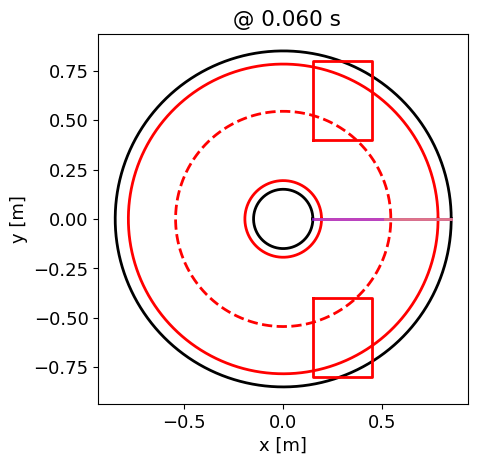

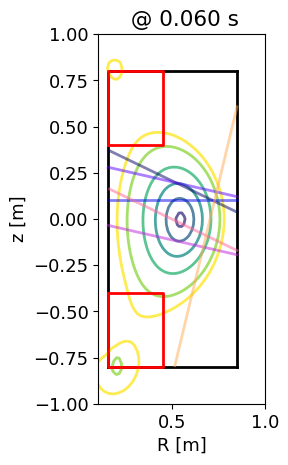

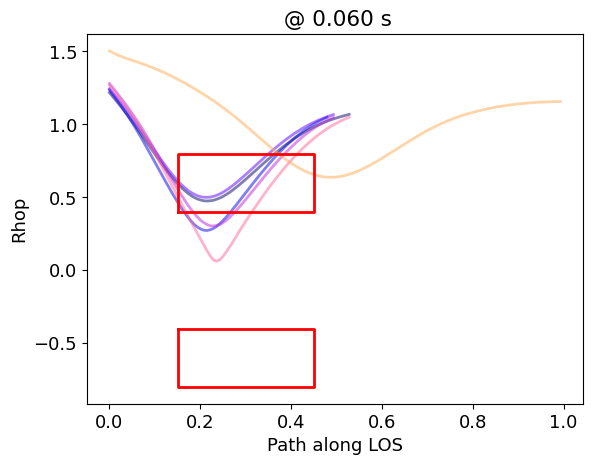

In [3]:

individual=[6.0, 16.0, 19.0, 331.0, 334.0, 60.0, -0.28571429, 0.0, -0.14285714, -0.14285714, -0.28571429,0.85]
N = len(individual) // 2
los_angles = individual[:N]
min_los_angle = np.min(los_angles)
offsets = individual[N:]
directions = []
origins = []
for i in range(N):
    new_origin_x, new_origin_z = origin_from_polar_angle(los_angles[i], transform)
    origins.append((new_origin_x, 0, new_origin_z))
    new_dir_x, new_dir_z = direction_from_polar_and_dir_offset(
        los_angles[i], offsets[i], transform
    )
    directions.append((new_dir_x, 0, new_dir_z))

transform.set_origin(np.array(origins))
transform.set_direction(np.array(directions))
update_los(transform)

a=transform.plot()


Emissivity shape: (9, 41)
Measurements shape: (9, 8)
<xarray.DataArray 'brightness' (t: 9, channel: 8)> Size: 576B
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.30336476e+06,  1.49251449e+06,  1.68573587e+06,  1.86193364e+06,  1.39344874e+06,
         6.17166549e+05,  1.78127373e+05,  6.86914989e+02],
       [ 1.36235078e+06,  1.55468522e+06,  1.75474090e+06,  2.00485242e+06,  1.67861903e+06,
         6.43418277e+05,  2

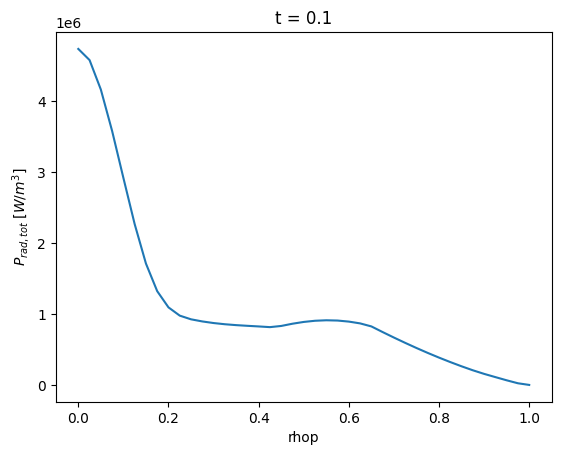

In [4]:
# Forward model -> measurements (brightness)
# This gives you a pair: (emissivity, measurements) for surrogate training.
bckc, emissivity = model(return_emissivity=True)
measurements = bckc["brightness"]
print("Emissivity shape:", emissivity.shape)
print("Measurements shape:", measurements.shape)
emissivity.sel(t=0.5, method="nearest").plot()
print(measurements)
print(emissivity)



## Plasma generator

In [5]:
from indica.workflows.plasma_profiler_init import load_bda_config, build_plasma_profiler, sample_prior_parameters

class PlasmaGenerator():
    def __init__(self, model,transform,config_name="ion_temperature_phantom_run_all_params"):
        self.model = model
        self.transform = transform
        self.cfg = load_bda_config(
            config_name="ion_temperature_phantom_run_all_params",
            overrides=[
                "plasma.settings.n_rad=41",
                "tstart=0.02",
                "tend=0.1",
                "dt=0.01",
            ],
            )
        self.plasma_profiler = build_plasma_profiler(self.cfg)

    def generate(self):
        all_params = sample_prior_parameters(self.cfg)
        self.plasma_profiler(all_params)
        return self.plasma_profiler.plasma
    
    def run_model(self,target_plasma=None):
        if target_plasma is not None:
            self.model.set_plasma(target_plasma)
        else:
            self.model.set_plasma(self.plasma_profiler.plasma)
            
        self.model.set_transform(self.transform)
        bckc, emissivity = self.model(return_emissivity=True)
        measurements = bckc["brightness"]
        return(measurements, emissivity)

    
    



## Data generation and writing

In [14]:
#Generate all the pairs of (emissivity, measurements) for the given plasma. 
#No temporal relations, each time step is independent for now.
b_slices=[]
eps_slices=[]
generate_new_data=True
b_dir="jussitesting/vae_firstpass/b_slices.csv"
eps_dir="jussitesting/vae_firstpass/eps_slices.csv"
if generate_new_data:
    
    import csv
    generator=PlasmaGenerator(model,transform)
    use_all_timepoints = False  # Set True when generator has meaningful time dynamics.
    for r in range(4000):
        if not r%200:
            print(f"Elapsed: {r}/2000")
        generator.generate()
        measurements, emissivity = generator.run_model()
        if use_all_timepoints:
            t_indices = range(measurements.sizes["t"])
        else:
            #If random index
            t_indices = [np.random.randint(measurements.sizes["t"])]
            #Central index
            #t_indices=[int(measurements.sizes["t"]/2)]
        for t_idx in t_indices:
            channel_vector = measurements.isel(t=t_idx).values.astype(np.float32)
            emissivity_slice = emissivity.isel(t=t_idx).values.astype(np.float32)
            b_slices.append(channel_vector)
            eps_slices.append(emissivity_slice)
    print(len(b_slices), len(eps_slices))
    b_slices=np.array(b_slices)
    eps_slices=np.array(eps_slices)
    print(b_slices.shape, eps_slices.shape)



    with open(b_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(b_slices)
    with open(eps_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(eps_slices)

        

/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'ion_temperature_phantom_run_all_params': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


no profile params given so updating all
Elapsed: 0/2000
Elapsed: 200/2000
Elapsed: 400/2000
Elapsed: 600/2000
Elapsed: 800/2000
Elapsed: 1000/2000
Elapsed: 1200/2000
Elapsed: 1400/2000
Elapsed: 1600/2000
Elapsed: 1800/2000
Elapsed: 2000/2000
Elapsed: 2200/2000
Elapsed: 2400/2000
Elapsed: 2600/2000
Elapsed: 2800/2000
Elapsed: 3000/2000
Elapsed: 3200/2000
Elapsed: 3400/2000
Elapsed: 3600/2000
Elapsed: 3800/2000
4000 4000
(4000, 6) (4000, 41)


## Dataset creation


In [15]:

from torch.utils.data import Dataset, DataLoader
import torch
class PairDataset(Dataset):
    def __init__(self, b_dir, eps_dir):
        self.b_dir = b_dir
        self.eps_dir = eps_dir
        self.b_slices = np.loadtxt(b_dir, delimiter=',',dtype=np.float32)
        self.eps_slices = np.loadtxt(eps_dir, delimiter=',',dtype=np.float32)
        self.mu_b, self.sigma_b = np.mean(self.b_slices), np.std(self.b_slices)
        self.mu_eps, self.sigma_eps = np.mean(self.eps_slices), np.std(self.eps_slices)


    def __len__(self):
        return len(self.b_slices)
    
    def __getitem__(self, idx):
        b_slice = self.b_slices[idx]
        eps_slice = self.eps_slices[idx]
        return(eps_slice-self.mu_eps)/self.sigma_eps,(b_slice-self.mu_b)/self.sigma_b

In [16]:
PairDataset(b_dir, eps_dir)
trainsplit, testsplit=torch.utils.data.random_split(PairDataset(b_dir, eps_dir), lengths=[int(0.8*len(PairDataset(b_dir, eps_dir))), len(PairDataset(b_dir, eps_dir)) - int(0.8*len(PairDataset(b_dir, eps_dir)))])

train_dataloader=DataLoader(trainsplit, batch_size=8, shuffle=True)
test_dataloader=DataLoader(testsplit, batch_size=8, shuffle=True)

print(len(train_dataloader))

400


## Sanity check

#### Notation
- $p_\theta$ denotes a generative model, parameterized by $\theta$
- $q_\phi$ denotes the variational approximation (encoder), parametrized by $\phi$ 
- In variational bayes, p is true model and q approximating dist. Also phi is inference parameter and theta generative parameter.


#### Currently we have:
- A collection of (6,) shaped bolometer signals $b$, each one is from a different time slice-> right now, consider time independent
- A matching collection of (41,) shaped emissivity signals $e$, same thing.
- We have a torch dataset defined for this, and this dataset has normalisation coefficients computed. Scale when we  call getitem.

#### Conceptual model definiton - dummy edition

Three random variables:
1) Emissivity $e \in \real^{41}$. What we observe during training, this is what the model targets.
2) Latent variable $z \in \real^{d}$. Unobserved.
3) Bolometry $b \in \real^{6}$. Observed and conditioned on. 

ie. Given $b$, sample $z$, then generate $e$.

#### Decoder 

1) Draw a latent variable from a standard normal: $Z \sim \mathcal{N}(0,I)$ 
2) Given a bolometer measurement $b$ and a latent variable $z$, the emissivity follows a distribution parametrized by the decoder network:  $e | (b,z) \sim p_{\theta}(e | b,z)$
3) When conditioned on $b$ and $z$, the emissivity follows a Gaussian whose mean is predicted by the decoder network, covariance is identity ie. decoder only predicts the mean emissivity, all remaining uncertainty is represented by $z$ ie.  $p_{\theta}(e | b,z) = \mathcal{N}(\mu_\theta (b,z),I)$.

#### Encoder
1) The approximate posterior over $z$, conditioned on both $e$ and $b$, $q_{\phi}(z|e,b)$, $= \mathcal{N}(\mu_z (e,b), diag (\sigma^2_z (e,b)))$. The encoder takes emissivity and bolometer inputs, and outputs mean and variacne of a Gaussian over $z$.
2) This is same as saying "which latent variables could have plausibly produced the observed emissivity, when combined with the bolometry?"

#### Training

1) We take an emissivity and bolometry inputs and then when given into the encoder, the encoder gives the Gaussian parameters for the latent variable as: $(\mu_z,\sigma_z) =Encoder(e,b)$
2) Sample the latent by adding gaussian noise to encoder mean scaled with the predicted sd: $z=\mu_z+\sigma_z \odot \epsilon, \epsilon \sim \mathcal{N}(0,I)$. 
3) Last step used reparametrization trick. Since Z is sampled, and sampling is not differentiable, gradients cannot flow through a random draw. Instead of sampling from the gaussian whose params I am trying to learn, I take standard noise and transform this using the params I wanna learn. This becomes differentiable and gradients can flow through!
4) Decode: decoder takes bolometer measurement and sampled latent, and outputs a predicted emissivity profile $\hat{e}=\mu_\theta (b,z)$


#### Loss
1) Reconstruction term, square difference between true emissivity and predicted: $||e-\hat{e}||^2$. We assume Gaussian with unit variance for decoder, so squared error is proportional to negative log-likelihood of true emissivity under the model. DO the math! 
2) KL-divegence term: Measures how different the encoders inferred latent dist is from a standard noraml. Basically, this means the encoder has to use the bolometer as well and not just try to hide everything behind the latent variables:
$KL(q_\phi (z|e,b) || \mathcal{N}(0,I))$

3) The combined loss: model is trained to reconstruct the observed emissivity and keep the latent variables close to a Gaussian. $\mathcal{L} = \mathbb{E}_{q_\theta (z|e,b)}[||e-\hat{e}||^2]+KL(q_\phi (z|e,b) || \mathcal{N}(0,I))$. ANother wording: First loss term is the squared recosnstruction error in the emissivity, when expectation is taken wrt the approximate posterior over the latent variables and standard normal prior.


Basically: 


#### Inference time
1) Encoder is not used
2) Sample from latent, and let decoder figure what the emissivity would be based on that.

## cVAE structure and training

In [ ]:
#Note that encoder takes in 41+6! I changed dataloader order.
from torch import nn
import torch

latent_dim=4


class Network(nn.Module):
    def __init__(self, input_dim=47, latent_dim=4):
        super(Network, self).__init__()
        self.fc1m = nn.Linear(input_dim, 64)
        self.fc1s = nn.Linear(input_dim, 64)

        self.fc2m = nn.Linear(64, 32)
        self.fc2s = nn.Linear(64, 32)
        
        self.fc3m = nn.Linear(32, latent_dim)
        self.fc3s = nn.Linear(32, latent_dim)



        self.fc_dec1 = nn.Linear(latent_dim + 6, 32)
        self.fc_dec2 = nn.Linear(32, 64)
        self.fc_dec3 = nn.Linear(64, 41)
    #encode
    def encode(self, emis, bolom ):
        x = torch.cat((emis, bolom), dim=1)

        m = torch.relu(self.fc1m(x))
        logvar = torch.relu(self.fc1s(x))

        m = torch.relu(self.fc2m(m))
        logvar = torch.relu(self.fc2s(logvar))
        
        m = self.fc3m(m)
        logvar = self.fc3s(logvar)
        return m, logvar
    
    def decode(self, b,z):
        x=torch.cat((b,z), dim=1)
        x = torch.relu(self.fc_dec1(x))
        x = torch.relu(self.fc_dec2(x))
        x = self.fc_dec3(x)
        return x

    def reparametrize(self,m, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return m + eps * std
    
    def KL_divergence(self, m, logvar):
        return -0.5 * torch.sum(1 + logvar - m.pow(2) - logvar.exp(), dim=1)
    
    def total_loss(self, recon_x, x, m, logvar, return_components=False, kl_beta=0):
        recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
        kl_loss = self.KL_divergence(m, logvar).sum()
        #print("Recon mean: ", recon_loss.item()/x.shape[0], "KL mean: ", kl_loss.item()/x.shape[0])
        total = (recon_loss + kl_beta * kl_loss) / x.shape[0]
        if return_components:
            return total, recon_loss / x.shape[0], kl_loss*kl_beta / x.shape[0]
        return total
    

    def forward(self, emis, bolom):
        m, logvar = self.encode(emis, bolom)
        z = self.reparametrize(m, logvar)
        e_hat = self.decode(bolom, z)
        return e_hat, m, logvar, z
    

def train(model, epoch, optimizer, n_epochs=30):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0
    kl_epoch_beta = epoch / n_epochs
    for batch_idx, (emis, bolom) in enumerate(train_dataloader):
        optimizer.zero_grad()
        recon_emis, m, logvar, z = model(emis, bolom)
        loss,rec,kl = model.total_loss(recon_emis, emis, m, logvar, return_components=True,kl_beta=kl_epoch_beta)
        loss.backward()
        train_loss += loss.item()
        recon_loss_total += rec.item()
        kl_loss_total += kl.item()
        optimizer.step()
    print(f'====> Epoch: {epoch} Average loss: {train_loss/len(train_dataloader):.4f}')
    print(f'====> Epoch: {epoch} Average recon loss: {recon_loss_total/len(train_dataloader):.4f} Average KL loss: {kl_loss_total/len(train_dataloader):.4f}')
    
vaemodel=Network(latent_dim=latent_dim)
total_params = sum(p.numel() for p in vaemodel.parameters())
print(f"Total number of parameters in the VAE model: {total_params}")
optimizer=torch.optim.Adam(vaemodel.parameters(), lr=1e-3)
n_epochs=10
for epoch in range(1, n_epochs): 
    train(vaemodel,epoch,optimizer,n_epochs=n_epochs)

Total number of parameters in the VAE model: 15697
====> Epoch: 1 Average loss: 5.8791
====> Epoch: 1 Average recon loss: 5.4563 Average KL loss: 0.4228
====> Epoch: 2 Average loss: 0.8900
====> Epoch: 2 Average recon loss: 0.6240 Average KL loss: 0.2660
====> Epoch: 3 Average loss: 0.7894
====> Epoch: 3 Average recon loss: 0.5603 Average KL loss: 0.2291
====> Epoch: 4 Average loss: 0.7063
====> Epoch: 4 Average recon loss: 0.4831 Average KL loss: 0.2231
====> Epoch: 5 Average loss: 0.7333
====> Epoch: 5 Average recon loss: 0.5182 Average KL loss: 0.2150
====> Epoch: 6 Average loss: 0.6839
====> Epoch: 6 Average recon loss: 0.4844 Average KL loss: 0.1995
====> Epoch: 7 Average loss: 0.6669
====> Epoch: 7 Average recon loss: 0.5088 Average KL loss: 0.1581
====> Epoch: 8 Average loss: 0.5290
====> Epoch: 8 Average recon loss: 0.4338 Average KL loss: 0.0951
====> Epoch: 9 Average loss: 0.4817
====> Epoch: 9 Average recon loss: 0.4328 Average KL loss: 0.0489
====> Epoch: 10 Average loss: 0

## Sanity checks: diversity and fw consistency metrics: one set of values and intuition



### Conditional sampling diversity
- Mean L2 distance to sample-mean : 0.057555 -> Average spread of the posterior ie. how far are samples from the posterior mean? How concentrated is my posterior?
- Max per-dim std: 0.103400  -> In regions where the uncertainty is the strongest, how strong is it?
- L2(sample-mean, true e): 0.061272 -> Bias of the posterior mean. Is posterior centered correctly around the true value?


### Forward consistency

- Mean L2: 0.095481 -> Are the sampled emissivities consistent with the conditioning measurement? If large, posterior samples do not adhere to the bolometry measurement conditioning.
- Max abs error : 0.213974 -> Largest single bolometer channel inconsistency. Fw model measurements vs the actual measurements!

In [33]:
import torch

vaemodel.eval()

K = 100
idx = 10  

# Single example from the dataset
test_dataset = test_dataloader.dataset
e_true, b_star = test_dataset[idx]          
e_true = torch.from_numpy(e_true).unsqueeze(0)                
b_star = torch.from_numpy(b_star).unsqueeze(0)                

#Latent dim
latent_dim = vaemodel.fc3m.out_features

with torch.no_grad():
    # Sample K latents
    z = torch.randn(K, latent_dim)           
    # Repeat b* K times
    b_rep = b_star.expand(K, -1)                            

    # Decode K samples
    e_samps = vaemodel.decode(b_rep, z)                     

#  Use the same dataset object for stats. It has mu and sigma for unnormalization.
subset=test_dataloader.dataset
dataset=subset.dataset

#Diversity metrics


with torch.no_grad():
    #unnormalize samples and true value
    e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
    e_true_un  = e_true  * dataset.sigma_eps + dataset.mu_eps

    e_mean_un = e_samps_un.mean(dim=0, keepdim=True)        
    l2_to_mean = torch.norm(e_samps_un - e_mean_un, dim=1)  
    mean_l2 = l2_to_mean.mean().item()

    std_per_dim = e_samps_un.std(dim=0)                     # (41,)
    mean_std = std_per_dim.mean().item()
    max_std  = std_per_dim.max().item()

    e_scale = torch.norm(e_true_un, dim=1).item() + 1e-8
    mean_l2_norm  = mean_l2 / e_scale
    mean_std_norm = mean_std / (e_scale / (e_true_un.shape[1] ** 0.5))
    max_std_norm  = max_std  / (e_scale / (e_true_un.shape[1] ** 0.5))

print("Conditional sampling diversity")
print(f"K = {K}, idx = {idx}")
print(f"Mean L2 distance to sample-mean (norm): {mean_l2_norm:.6f}")
print(f"Mean per-dim std (norm): {mean_std_norm:.6f}")
print(f"Max  per-dim std (norm): {max_std_norm:.6f}")

err_to_true = torch.norm(e_mean_un - e_true_un, dim=1).item()
print(f"L2(sample-mean, true e) (norm): {(err_to_true / e_scale):.6f}")

# FW consistency metrics
e_all = torch.as_tensor(dataset.eps_slices)  # (N,41) unnormalized
b_all = torch.as_tensor(dataset.b_slices)   # (N,6)  unnormalized
A = torch.linalg.lstsq(e_all, b_all).solution               # (41,6)

with torch.no_grad():
    b_star_un = b_star * dataset.sigma_b + dataset.mu_b
    b_hat = e_samps_un @ A
    diff = b_hat - b_star_un

    l2 = torch.norm(diff, dim=1)
    mean_l2 = l2.mean().item()
    rmse = torch.sqrt((diff ** 2).mean()).item()
    max_abs = diff.abs().max().item()

    b_scale = torch.norm(b_star_un, dim=1).item() + 1e-8
    mean_l2_norm = mean_l2 / b_scale
    rmse_norm = rmse / (b_scale / (b_star_un.shape[1] ** 0.5))
    max_abs_norm = max_abs / (b_scale / (b_star_un.shape[1] ** 0.5))

print("Forward consistency (linear surrogate)")
print(f"Mean L2(b_hat, b*): {mean_l2_norm:.6f}")
print(f"RMSE : {rmse_norm:.6f}")
print(f"Max abs error : {max_abs_norm:.6f}")



Conditional sampling diversity
K = 100, idx = 10
Mean L2 distance to sample-mean (norm): 0.014365
Mean per-dim std (norm): 0.015511
Max  per-dim std (norm): 0.025395
L2(sample-mean, true e) (norm): 0.036987
Forward consistency (linear surrogate)
Mean L2(b_hat, b*): 0.030600
RMSE : 0.030950
Max abs error : 0.073689


/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'ion_temperature_phantom_run_all_params': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


no profile params given so updating all
(9, 41)
(9, 6)
<xarray.DataArray (t: 9, rhop: 41)> Size: 3kB
array([[2.85456960e+05, 2.85447964e+05, 2.85415737e+05, 2.85352383e+05, 2.85249903e+05,
        2.85100107e+05, 2.84894505e+05, 2.84623990e+05, 2.84277027e+05, 2.83840223e+05,
        2.83299226e+05, 2.82637842e+05, 2.81832648e+05, 2.80855663e+05, 2.79676926e+05,
        2.78258590e+05, 2.76552904e+05, 2.74509124e+05, 2.72066730e+05, 2.69152262e+05,
        2.66136865e+05, 2.62706039e+05, 2.58560888e+05, 2.53587301e+05, 2.47652265e+05,
        2.40619342e+05, 2.32349834e+05, 2.23832849e+05, 2.14711745e+05, 2.03738121e+05,
        1.90735572e+05, 1.75632984e+05, 1.63208159e+05, 1.47649102e+05, 1.28450974e+05,
        1.13238754e+05, 9.92089805e+04, 7.75012588e+04, 4.25902789e+04, 1.08527100e+04,
        3.18775228e+02],
       [5.25605296e+05, 5.24977794e+05, 5.23129874e+05, 5.20111368e+05, 5.15969890e+05,
        5.10751478e+05, 5.04501202e+05, 4.97267752e+05, 4.89142623e+05, 4.80243899

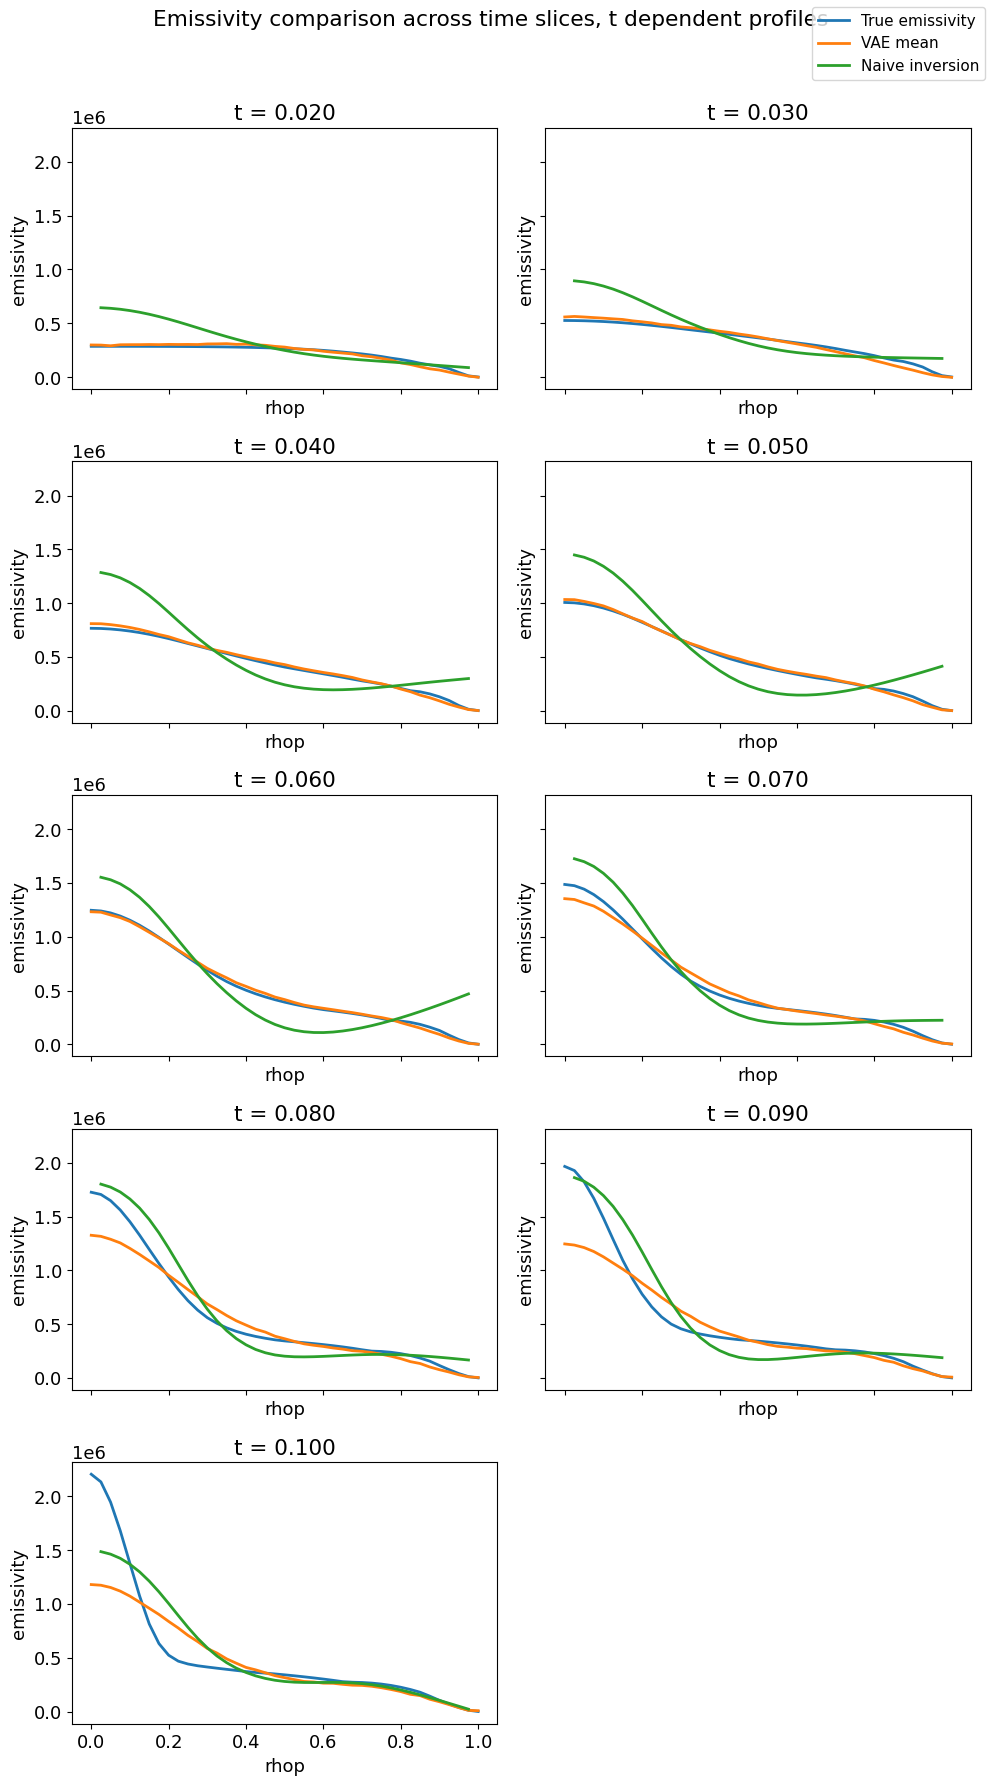

In [34]:
#Tomography inversion vs vae across time slices for a time dependent plasma
from indica.workflows.los_bolometry_radiation import calculate_tomo_inversion
import xarray as xr

# Dataset stats for normalization
dataset = PairDataset(b_dir, eps_dir)

# Use the model to get a brightness/emissivity time series
generator=PlasmaGenerator(model,transform)
#generator.generate()
plasma = load_default_objects(machine, "plasma")
plasma.set_equilibrium(equilibrium)
brightness, emissivity_tmp=generator.run_model(target_plasma=plasma)
print(emissivity_tmp.shape)
print(brightness.shape)
print(emissivity_tmp)

# Select one timepoint or all timepoints
use_all_timepoints_plot = True
if use_all_timepoints_plot:
    t_indices = np.arange(brightness.sizes["t"], dtype=int)
else:
    t_indices = np.array([np.random.randint(brightness.sizes["t"])] , dtype=int)

# Compute tomography inversion only for selected times
brightness_sel = brightness.isel(t=t_indices)
print("Selected brightness shape for tomography:", brightness_sel.shape)
tomo_inv = calculate_tomo_inversion(brightness_sel, model.transform, emissivity_tmp.rhop)

# Plot comparisons
if len(t_indices) == 1:
    fig, axes = plt.subplots(1, 1, figsize=(6, 4))
    axes = np.array([axes])
else:
    n_cols = 2
    n_rows = int(np.ceil(len(t_indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.5 * n_rows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

for ax in axes[len(t_indices):]:
    ax.axis("off")

for ax, ti, ti_sel in zip(axes[:len(t_indices)], t_indices, range(len(t_indices))):
    # True emissivity at time ti
    e_true = emissivity_tmp.isel(t=ti).values

    # VAE: normalize brightness, sample K, decode, then unnormalize emissivity
    b_t = brightness.isel(t=ti).values.astype(np.float32)
    b_t_norm = (b_t - dataset.mu_b) / dataset.sigma_b
    b_t_norm = torch.from_numpy(b_t_norm).unsqueeze(0)

    K = 20
    latent_dim = vaemodel.fc3m.out_features
    z = torch.randn(K, latent_dim)
    b_rep = b_t_norm.expand(K, -1)
    with torch.no_grad():
        e_samps = vaemodel.decode(b_rep, z)
        e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
        e_vae = e_samps_un.mean(dim=0).cpu().numpy()

    # Tomography inversion at time ti
    e_tomo = tomo_inv.isel(t=ti_sel).values

    ax.plot(emissivity_tmp.rhop, e_true, label="True emissivity")
    ax.plot(emissivity_tmp.rhop, e_vae, label="VAE mean")
    ax.plot(emissivity_tmp.rhop, e_tomo, label="Naive inversion")
    ax.set_title(f"t = {float(brightness.t.values[ti]):.3f}")
    ax.set_xlabel("rhop")
    ax.set_ylabel("emissivity")

# One legend for all
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Emissivity comparison across time slices, t dependent profiles", y=1.02)
fig.tight_layout()


Used 100/100 plasmas (after NaN filtering)
VAE RMSE:  mean=17685.0684  std=16634.4160
Tomo RMSE: mean=188146.2656  std=237466.6875


Text(0.02, 0.98, 'VAE wins: 94.0%\nmedian Δ=92505.3438')

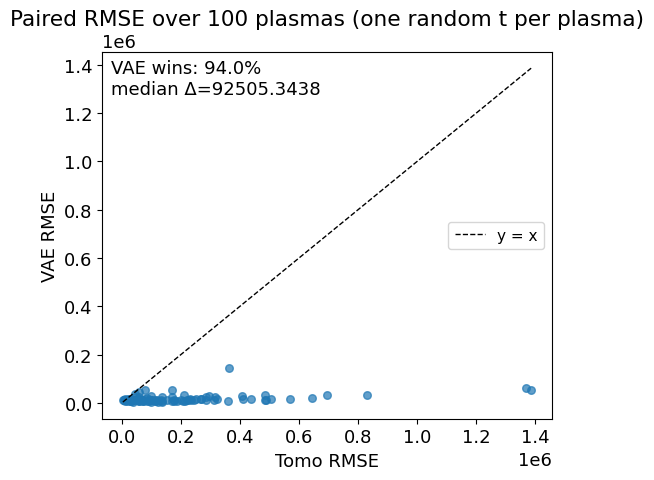

In [35]:
# Compare VAE vs 1D tomography over multiple generated plasmas
import numpy as np
import torch

n_plasmas = 100
K = 50

dataset = PairDataset(b_dir, eps_dir)
latent_dim = vaemodel.fc3m.out_features

vae_rmse = []
tomo_rmse = []

rng = np.random.default_rng(0)  # reproducible time index selection
use_all_timepoints_eval = False  # Set True when generated plasma has meaningful time dynamics.

for i in range(n_plasmas):
    generator.generate()
    measurements, emissivity = generator.run_model()

    if use_all_timepoints_eval:
        t_indices = np.arange(measurements.sizes["t"], dtype=int)
    else:
        t_indices = np.array([int(rng.integers(0, measurements.sizes["t"]))], dtype=int)

    # Tomography inversion only for selected times
    tomo_inv = calculate_tomo_inversion(measurements.isel(t=t_indices), model.transform, emissivity.rhop)

    for ti_sel, t0 in enumerate(t_indices):
        # Ground truth emissivity
        e_true = emissivity.isel(t=t0).values.astype(np.float32)

        # Tomography inversion
        e_tomo = tomo_inv.isel(t=ti_sel).values.astype(np.float32)

        # VAE inversion
        b_t = measurements.isel(t=t0).values.astype(np.float32)
        b_t_norm = (b_t - dataset.mu_b) / dataset.sigma_b
        b_t_norm = torch.from_numpy(b_t_norm).unsqueeze(0)

        z = torch.randn(K, latent_dim)
        b_rep = b_t_norm.expand(K, -1)
        with torch.no_grad():
            e_samps = vaemodel.decode(b_rep, z)
            e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
            e_vae = e_samps_un.mean(dim=0).cpu().numpy()

        # Filter NaNs from tomography (and align true/vae)
        valid = np.isfinite(e_tomo) & np.isfinite(e_true) & np.isfinite(e_vae)
        if not np.any(valid):
            continue

        e_true_v = e_true[valid]
        e_tomo_v = e_tomo[valid]
        e_vae_v = e_vae[valid]

        # RMSE across rhop (valid points only)
        vae_rmse.append(np.sqrt(np.mean((e_vae_v - e_true_v) ** 2)))
        tomo_rmse.append(np.sqrt(np.mean((e_tomo_v - e_true_v) ** 2)))

vae_rmse = np.array(vae_rmse)
tomo_rmse = np.array(tomo_rmse)

print(f'Used {len(vae_rmse)}/{n_plasmas} plasmas (after NaN filtering)')
print(f'VAE RMSE:  mean={vae_rmse.mean():.4f}  std={vae_rmse.std():.4f}')
print(f'Tomo RMSE: mean={tomo_rmse.mean():.4f}  std={tomo_rmse.std():.4f}')

# Paired scatter with y=x line
plt.figure(figsize=(5.5, 5))
plt.scatter(tomo_rmse, vae_rmse, alpha=0.7, s=30)
mn = min(tomo_rmse.min(), vae_rmse.min())
mx = max(tomo_rmse.max(), vae_rmse.max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='y = x')
plt.xlabel('Tomo RMSE')
plt.ylabel('VAE RMSE')
eval_mode_txt = 'all t per plasma' if use_all_timepoints_eval else 'one random t per plasma'
plt.title(f'Paired RMSE over {n_plasmas} plasmas ({eval_mode_txt})')
plt.legend()
plt.tight_layout()

# Win rate + median delta text (still helpful context)
delta = tomo_rmse - vae_rmse
win_rate = 100.0 * np.mean(delta > 0)
plt.gca().text(0.02, 0.98,
             f'VAE wins: {win_rate:.1f}%\nmedian Δ={np.median(delta):.4f}',
             transform=plt.gca().transAxes, va='top')


/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'ion_temperature_phantom_run_all_params': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


no profile params given so updating all


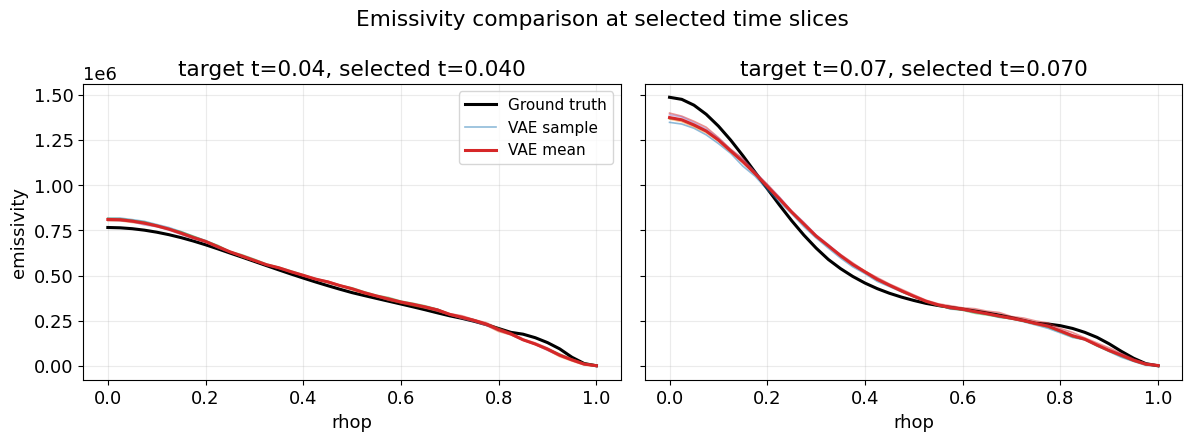

In [36]:
# Subplots at fixed time slices: t=0.04 and t=0.07
import numpy as np
import torch
import matplotlib.pyplot as plt

dataset = PairDataset(b_dir, eps_dir)

generator=PlasmaGenerator(model,transform)
#generator.generate()
plasma = load_default_objects(machine, "plasma")
plasma.set_equilibrium(equilibrium)
brightness, emissivity_tmp=generator.run_model(target_plasma=plasma)

target_times = [0.04, 0.07]
n_samples = 5
latent_dim = vaemodel.fc3m.out_features
t_values = np.asarray(brightness.t.values, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

for ax, t_target in zip(axes, target_times):
    t_idx = int(np.argmin(np.abs(t_values - t_target)))
    t_sel = float(t_values[t_idx])

    e_true = emissivity_tmp.isel(t=t_idx).values.astype(np.float32)
    b_t = brightness.isel(t=t_idx).values.astype(np.float32)
    b_t_norm = torch.from_numpy((b_t - dataset.mu_b) / dataset.sigma_b).unsqueeze(0)

    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        b_rep = b_t_norm.expand(n_samples, -1)
        e_samps = vaemodel.decode(b_rep, z)
        e_samps_un = (e_samps * dataset.sigma_eps + dataset.mu_eps).cpu().numpy()

    e_vae_mean = e_samps_un.mean(axis=0)

    ax.plot(emissivity_tmp.rhop, e_true, color="k", linewidth=2.2, label="Ground truth")
    for i in range(n_samples):
        label = "VAE sample" if i == 0 else None
        ax.plot(emissivity_tmp.rhop, e_samps_un[i], alpha=0.5, linewidth=1.2, label=label)
    ax.plot(emissivity_tmp.rhop, e_vae_mean, color="tab:red", linewidth=2.2, label="VAE mean")
    ax.set_title(f"target t={t_target:.2f}, selected t={t_sel:.3f}")
    ax.set_xlabel("rhop")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("emissivity")
axes[0].legend()
fig.suptitle("Emissivity comparison at selected time slices")
fig.tight_layout()
